# Canonical Marketing Campaign Analysis

## 1. Load Data





In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#load data from google drive
campaign_file_path = "/content/drive/MyDrive/Colab Notebooks/Marketing_Campaing_Analysis/Exercise data - campaigns.csv"
leads_file_path = "/content/drive/MyDrive/Colab Notebooks/Marketing_Campaing_Analysis/Exercise data - leads.csv"
pages_file_path = "/content/drive/MyDrive/Colab Notebooks/Marketing_Campaing_Analysis/Exercise data - pages.csv"

campaigns_df = pd.read_csv(campaign_file_path)
leads_df = pd.read_csv(leads_file_path)
pages_df = pd.read_csv(pages_file_path)
campaigns_df.head() #preview some of the data in the file
leads_df.head() #preview some of the data in the file
pages_df.head() #preview some of the data in the file

,page_url,date,page_views,page_avg_time,page_bounce_rate
0,ubuntu.com/engage/dockerandros,20211216.0,"3,853",0:01:00,86.98%
1,ubuntu.com/engage/dockerandros,20211214.0,"3,179",0:00:55,86.65%
2,ubuntu.com/engage/dockerandros,20211207.0,"2,843",0:01:05,87.57%
3,ubuntu.com/engage/dockerandros,20211212.0,"2,777",0:01:04,87.88%
4,ubuntu.com/engage/dockerandros,20211217.0,"2,570",0:00:56,86.42%


## 2. Data Cleaning and Preprocessing

In [7]:
from datetime import datetime
#clean and convert columns
pages_df['page_views'] = pages_df['page_views'].str.replace(',', '').astype(int) #convert views to int
pages_df['page_bounce_rate'] = pages_df['page_bounce_rate'].str.replace('%', '').astype(float) #convert percentages to floats
pages_df['date'] = pd.to_datetime(pages_df['date'], format='%Y%m%d') #convert date format

leads_df['campaign_joined_date'] = pd.to_datetime(leads_df['campaign_joined_date'])

#convert avg time on page to seconds (easy to compare)
def time_to_seconds(t):
  """function to convert time from mm:ss to seconds"""
  try:
    dt = datetime.strptime(t.strip(), "%H:%M:%S")
    return (dt.hour*3600) + (dt.minute*60) + dt.second
  except:
    return np.nan

pages_df['page_avg_seconds'] = pages_df['page_avg_time'].apply(time_to_seconds)
leads_df.head()

,lead_hashed_id,campaign_joined_date,lead_job_title,lead_industry,lead_country,campaign_name,lead_source,lead_status,seniority
0,011c1b8f66f416ed05e466117839bc82,2021-12-08,student,NaN,DE,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,NaN,Disqualified,Education
1,0214109a8d2ea5665e250426e666d745,2021-06-10,se,NaN,BE,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,NaN,Disqualified,Other
2,02b78453c1a350f85dce07e6d1d135b5,2021-09-22,engineer,NaN,BD,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,NaN,Nurture,Individual Contributor
3,03f08c9e402a968fbad2ef8b6df881b3,2021-07-22,professor,NaN,US,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,NaN,Disqualified,Education
4,04e1a8cbf3cf2f13a1d2ae1177dd5b45,2021-07-12,student,NaN,IT,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,NaN,Disqualified,Education


In [8]:
campaigns_df.head()

,campaign_name,page_url
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,ubuntu.com/engage/securing-ros-on-robotics-pla...
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,ubuntu.com/engage/dockerandros
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,ubuntu.com/engage/ros-support


## 3. Merge the data (campaign data and their associated page data)

This helps to associate the campaigns with their performance

In [9]:
#merge
campaigns_pages_df = pd.merge(campaigns_df, pages_df, on="page_url", how="left")
campaigns_pages_df.head()

,campaign_name,page_url,date,page_views,page_avg_time,page_bounce_rate,page_avg_seconds
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,2021-04-21,53,0:01:42,84.00,102
1,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,2021-05-19,46,0:00:55,97.37,55
2,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,2021-03-24,42,0:01:52,85.71,112
3,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,2021-09-09,37,0:00:19,96.43,19
4,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,2021-01-26,35,0:02:24,81.82,144


## 4. Data Analysis and Visualisations

### Campaign Performance Overview (what's working, what's not working)

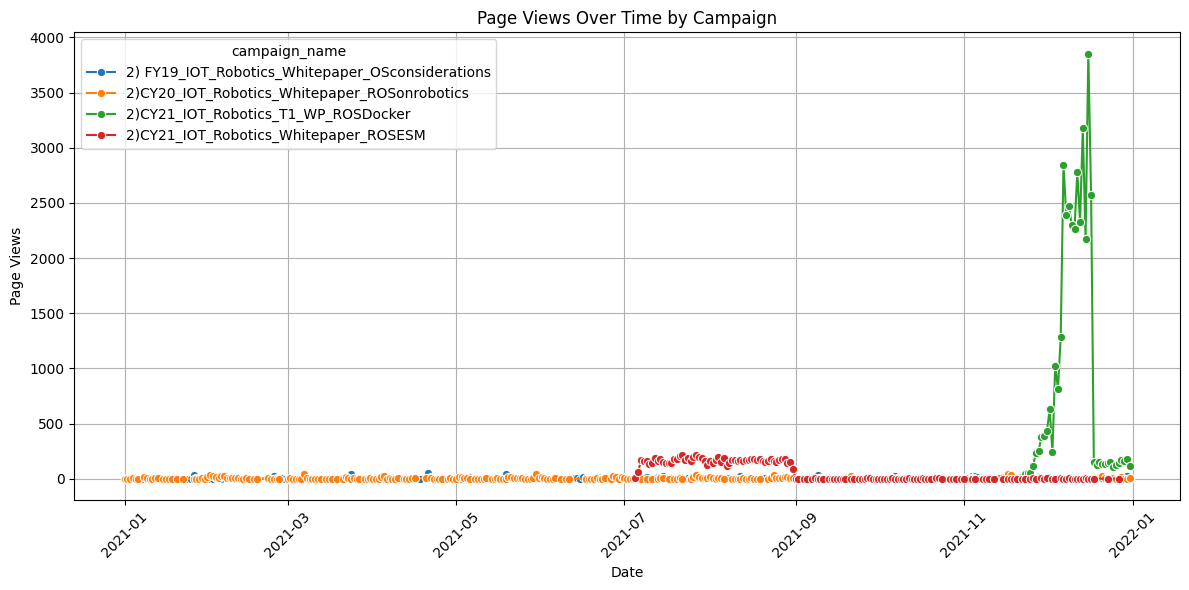

In [10]:
#PAGE VIEWS OVER TIME BY CAMPAIGN
plt.figure(figsize=(12, 6))
sns.lineplot(data=campaigns_pages_df, x='date', y='page_views', hue='campaign_name', marker='o')
plt.title('Page Views Over Time by Campaign')
plt.xlabel('Date')
plt.ylabel('Page Views')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# campaigns_pages_df.to_excel('campaigns_pages.xlsx', index=False)
# from google.colab import files
# files.download('campaigns_pages.xlsx')

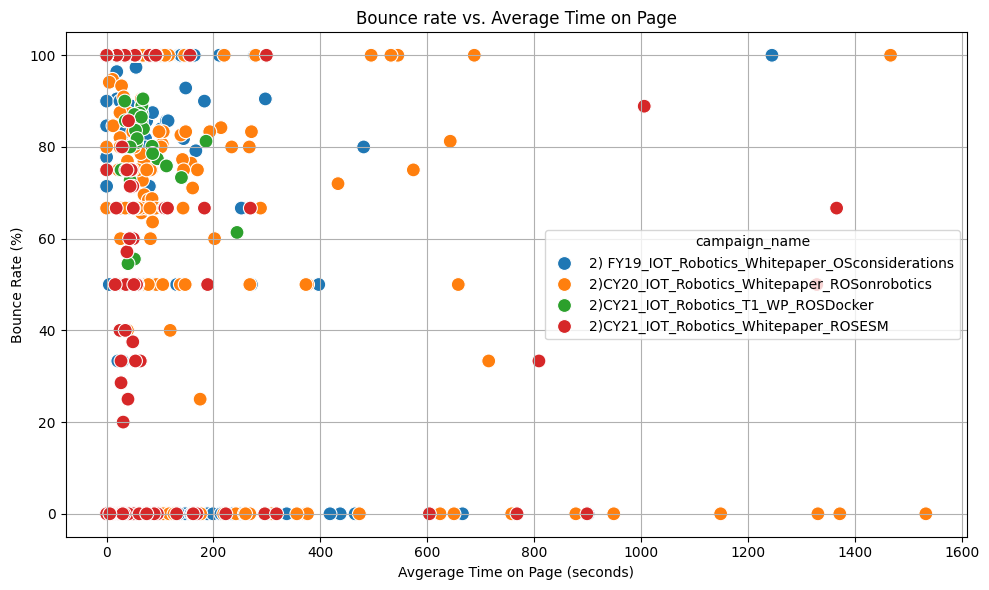

In [11]:
#BOUNCE RATE vs. AVERGAE TIME ON PAGE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=campaigns_pages_df, x='page_avg_seconds', y='page_bounce_rate', hue='campaign_name', s=100)
plt.title('Bounce rate vs. Average Time on Page')
plt.xlabel('Avgerage Time on Page (seconds)')
plt.ylabel('Bounce Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
#HIGH PERFORMING PAGES
high_performing_pages = pages_df[
    (pages_df['page_bounce_rate'] < 40) &
    (pages_df['page_avg_seconds']> 120)
]

print("High performing Pages (Bounce less than 40% and Time over 2 mins):")
# high_performing_pages_sum = high_performing_pages.groupby('page_url').agg({
#     'page_'
# })
high_performing_pages[['page_url', 'page_bounce_rate', 'page_avg_seconds', 'date']]

High performing Pages (Bounce less than 40% and Time over 2 mins):


,page_url,page_bounce_rate,page_avg_seconds,date
142,ubuntu.com/engage/dockerandros,0.0,298,2021-11-22
143,ubuntu.com/engage/robot-operating-system-choice,0.0,129,2021-05-04
166,ubuntu.com/engage/robot-operating-system-choice,0.0,184,2021-05-09
184,ubuntu.com/engage/robot-operating-system-choice,0.0,122,2021-08-31
189,ubuntu.com/engage/securing-ros-on-robotics-pla...,0.0,164,2021-08-13
...,...,...,...,...
762,ubuntu.com/engage/securing-ros-on-robotics-pla...,0.0,1372,2021-08-19
767,ubuntu.com/engage/securing-ros-on-robotics-pla...,0.0,126,2021-09-23
773,ubuntu.com/engage/securing-ros-on-robotics-pla...,0.0,260,2021-10-10
774,ubuntu.com/engage/securing-ros-on-robotics-pla...,0.0,309,2021-10-13


In [13]:
#AVERAGES PER PAGE/CAMPAIGN
campaign_averages = campaigns_pages_df.groupby('campaign_name').agg({
    'page_views':'sum',
    'page_bounce_rate':'mean',
    'page_avg_seconds':'mean'
}).reset_index()

campaign_averages = campaign_averages.round({
    'page_bounce_rate': 2,
    'page_avg_seconds':0
})

campaign_averages

,campaign_name,page_views,page_bounce_rate,page_avg_seconds
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,2048,51.22,68.0
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,1610,59.33,112.0
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,37122,78.97,74.0
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,9630,49.14,88.0


In [14]:
#CONSISTENT TRAFFIC/ GROWING OR DECLINING OR FLAT TRAFFIC
campaign_trends = campaigns_pages_df.groupby(['campaign_name', 'date'])['page_views'].sum().reset_index()

#clean 'page_views' column
campaign_trends['page_views'] = (
    campaign_trends['page_views']
    .astype(str)
    .str.replace(',', '')     #remove commas
    .astype(float)            #convert to float
)


def trend(df):
  """function to calculate the trend of page views over time per campaign"""
  if len(df) >= 3:
    return df['page_views'].corr(pd.Series(range(len(df))))
  return np.nan

all_trends = (
    campaign_trends
    .groupby('campaign_name', group_keys=False)
    .apply(lambda df: pd.Series({'view_trend_corr': trend(df)}))
    .reset_index()
)

all_trends['view_trend_corr'] = all_trends['view_trend_corr'].round(3)
all_trends['trend_flag'] = all_trends['view_trend_corr'].apply(
    lambda x: 'Growing' if x > 0.3 else 'Declining' if x < -0.3 else 'Flat/Unclear'
)

print("All trends:")
display(all_trends.sort_values(by='view_trend_corr', ascending=False))


All trends:


/tmp/ipykernel_16227/3931316815.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({'view_trend_corr': trend(df)}))


,campaign_name,view_trend_corr,trend_flag
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,0.044,Flat/Unclear
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,NaN,Flat/Unclear
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,NaN,Flat/Unclear
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,NaN,Flat/Unclear


In [15]:
# Count number of dates and std deviation per campaign, check why NaN appear??
campaign_inspection = campaign_trends.groupby('campaign_name').agg({
    'date': 'nunique',
    'page_views': 'std'
}).rename(columns={'date': 'num_dates', 'page_views': 'views_std'}).reset_index()

display(campaign_inspection)

#there is enough data to calculate a trend/correlation, maybe the NaN is due to the correlation being unclear

,campaign_name,num_dates,views_std
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,308,6.738032
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,295,7.431597
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,40,1132.631788
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,147,81.072297


In [16]:
#HIGH BOUNCE RATE
#average bounce rate per campaign
campaign_bounce = campaigns_pages_df.groupby('campaign_name')['page_bounce_rate'].mean().reset_index()
high_bounce_campaigns = campaign_bounce[campaign_bounce['page_bounce_rate'] > 60]

print("Campaigns with High Bounce Rate (>60%):")
high_bounce_campaigns


Campaigns with High Bounce Rate (>60%):


,campaign_name,page_bounce_rate
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,78.9655


In [17]:
#LOW ENGAGEMENT PAGES
low_engagement_pages =  campaigns_pages_df[campaigns_pages_df['page_avg_seconds'] < 30]

print("Low Engagement Pages (<30s avg time):")
low_engagement_pages[['campaign_name', 'page_url', 'page_avg_seconds']]


Low Engagement Pages (<30s avg time):


,campaign_name,page_url,page_avg_seconds
3,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,19
5,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,19
8,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,0
12,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,0
16,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,ubuntu.com/engage/robot-operating-system-choice,26
...,...,...,...
784,2)CY21_IOT_Robotics_Whitepaper_ROSESM,ubuntu.com/engage/ros-support,4
785,2)CY21_IOT_Robotics_Whitepaper_ROSESM,ubuntu.com/engage/ros-support,0
786,2)CY21_IOT_Robotics_Whitepaper_ROSESM,ubuntu.com/engage/ros-support,0
787,2)CY21_IOT_Robotics_Whitepaper_ROSESM,ubuntu.com/engage/ros-support,0


### Lead Quality Metrics

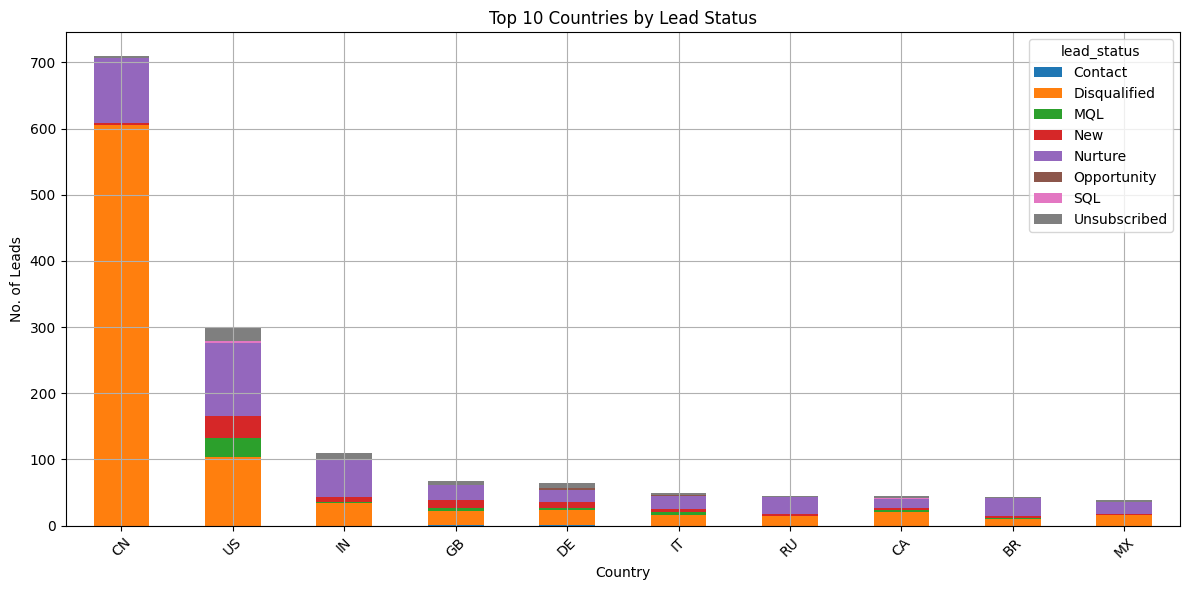

In [18]:
# LEADS BY COUNTRY AND STATUS
lead_country_status = leads_df.groupby(['lead_country', 'lead_status']).size().unstack(fill_value=0)
top_countries = lead_country_status.sum(axis=1).sort_values(ascending=False).head(10).index
lead_country_top = lead_country_status.loc[top_countries]

lead_country_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Top 10 Countries by Lead Status')
plt.xlabel('Country')
plt.ylabel('No. of Leads')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# LEADS BY CAMPAIGN
lead_quality = leads_df.groupby(['campaign_name', 'lead_status']).size().unstack(fill_value=0)
lead_quality

lead_status,Contact,Disqualified,MQL,New,Nurture,Opportunity,SQL,Unsubscribed
campaign_name,,,,,,,,
2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,1,105,6,0,101,2,0,29
2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,2,64,8,42,91,1,1,27
2)CY21_IOT_Robotics_T1_WP_ROSDocker,4,890,63,105,456,0,3,36
2)CY21_IOT_Robotics_Whitepaper_ROSESM,0,163,3,23,265,2,0,47


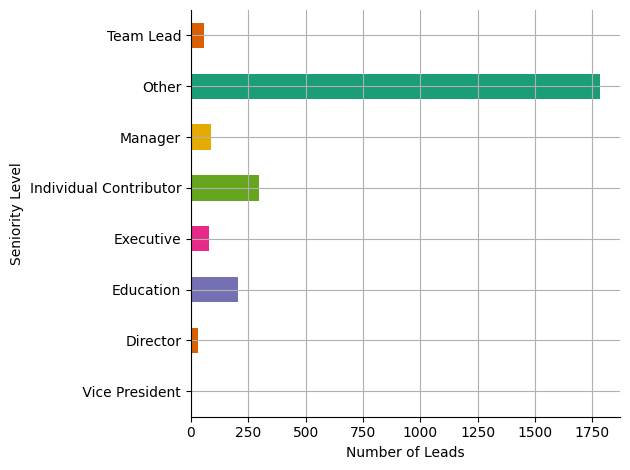

In [20]:
#JOB TITLE DISTRIBUTION
leads_df['lead_job_title'] = leads_df['lead_job_title'].astype(str).str.lower()

def classify_seniority(title):
  """function to classify lead job titles be senority"""
  if 'chief' in title or 'cxo' in title or 'ceo' in title or 'executive' in title:
    return 'Executive'
  elif 'vp' in title or 'vice president' in title:
    return ' Vice President'
  elif 'director' in title:
    return 'Director'
  elif 'manager' in title:
    return 'Manager'
  elif 'lead' in title or 'head' in title:
    return 'Team Lead'
  elif 'engineer' in title or 'developer' in title or 'analyst' in title:
    return 'Individual Contributor'
  elif 'student' in title or 'professor' in title or 'teacher' in title:
    return 'Education'
  else:
    return 'Other'

leads_df['seniority'] = leads_df['lead_job_title'].apply(classify_seniority)

#visualisation
leads_df.groupby('seniority').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlabel('Number of Leads')
plt.ylabel('Seniority Level')
plt.tight_layout()
plt.grid()


In [21]:
#TRAFFIC VS LEADS
#count leads per campaign
leads_per_campaign = leads_df['campaign_name'].value_counts().reset_index()
leads_per_campaign.columns = ['campaign_name', 'num_leads']

#count traffic per campaign
traffic_per_campaign = campaigns_pages_df.groupby('campaign_name')['page_views'].sum().reset_index()
traffic_per_campaign.columns = ['campaign_name', 'total_page_views']

#merge traffic and leads data
campaign_leads_traffic = pd.merge(traffic_per_campaign, leads_per_campaign, on='campaign_name', how='left').fillna(0)

#calculate lead conversion rate
campaign_leads_traffic['lead_conversion_rate'] = campaign_leads_traffic['num_leads'] / campaign_leads_traffic['total_page_views']

#top campaigns for conversion
top_converting_campaigns = campaign_leads_traffic.sort_values('lead_conversion_rate', ascending=False)
display(top_converting_campaigns.head(2)) #top 2

,campaign_name,total_page_views,num_leads,lead_conversion_rate
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,1610,236,0.146584
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,2048,244,0.119141


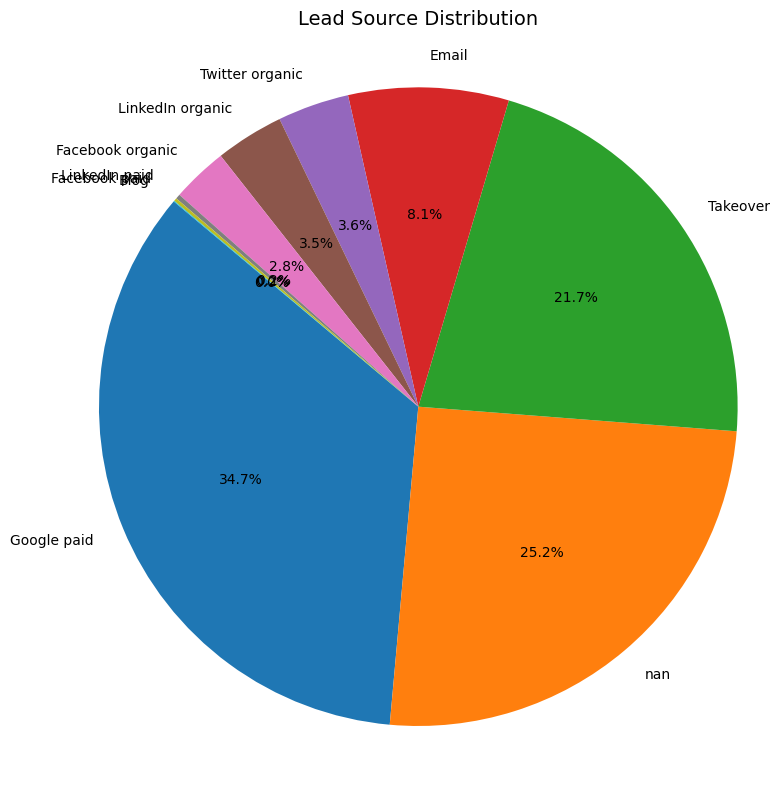

In [22]:
#LEAD SOURCES
lead_source_counts = leads_df['lead_source'].value_counts(dropna=False)

#pie chart to view data
plt.figure(figsize=(8,8))
plt.pie(
    lead_source_counts,
    labels=lead_source_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize':10}
)
plt.title('Lead Source Distribution', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [23]:
for lead_source in lead_source_counts.index:
  print(lead_source)

Google paid
nan
Takeover
Email
Twitter organic
LinkedIn organic
Facebook organic
LinkedIn paid
Facebook paid
Blog


### Key Performance Metrics

Primary KPIs

In [28]:
#TRAFFIC QUALITY SCORE: (page_views*avg_time)/bounce_rate
#to avoid division by zero that is affecting the calculation
pages_df['page_bounce_rate_safe'] = pages_df['page_bounce_rate'].replace(0, 0.1)
pages_df['traffic_quality_score'] = (pages_df['page_views'] * pages_df['page_avg_seconds']) / pages_df['page_bounce_rate_safe']
pages_df.replace({'traffic_quality_score':[np.inf, -np.inf]}, np.nan, inplace=True) #replace any large numbers or NaNs
pages_df['traffic_quality_score'] = pages_df['traffic_quality_score'].round(2)
pages_df[['traffic_quality_score', 'page_bounce_rate', 'page_views', 'page_avg_seconds', 'page_url']]

,traffic_quality_score,page_bounce_rate,page_views,page_avg_seconds,page_url
0,2657.85,86.98,3853,60,ubuntu.com/engage/dockerandros
1,2017.83,86.65,3179,55,ubuntu.com/engage/dockerandros
2,2110.25,87.57,2843,65,ubuntu.com/engage/dockerandros
3,2022.39,87.88,2777,64,ubuntu.com/engage/dockerandros
4,1665.36,86.42,2570,56,ubuntu.com/engage/dockerandros
...,...,...,...,...,...
786,330.00,0.00,1,33,ubuntu.com/engage/securing-ros-on-robotics-pla...
787,920.00,0.00,1,92,ubuntu.com/engage/securing-ros-on-robotics-pla...
788,610.00,0.00,1,61,ubuntu.com/engage/securing-ros-on-robotics-pla...
789,0.00,100.00,1,0,ubuntu.com/engage/securing-ros-on-robotics-pla...


In [29]:
#LEAD GENERATION RATE: leads per 1000 page views by campaign
#count leads by campaign
leads_count = leads_df.groupby('campaign_name').size().rename('leads_count').reset_index()

#sum page views by campaign
campaigns_pages_df = campaigns_pages_df.groupby('campaign_name')['page_views'].sum().reset_index()

#combine both
campaign_metrics = leads_count.merge(campaigns_pages_df, on='campaign_name', how='outer').fillna(0)

#calculate leads per 1000 views
campaign_metrics['lead_generation_rate'] = campaign_metrics['leads_count'] / campaign_metrics['page_views'] * 1000
campaign_metrics

,campaign_name,leads_count,page_views,lead_generation_rate
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,244,2048,119.140625
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,236,1610,146.583851
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,1557,37122,41.942783
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,503,9630,52.232606


In [30]:
#APPROX. ENGAGEMENT SCORE: time on page + pages per session (missing this data)
#approximate pages per session as 1/bounce rate (assumes lower bounce rate means more pages per session)
pages_df['pages_per_session'] = 100 / pages_df['page_bounce_rate'] #rough inverse

#engagement score per page/campaign
pages_df['engagement_score'] = pages_df['page_avg_seconds'] + pages_df['pages_per_session']
pages_df[['engagement_score', 'page_url']]

,engagement_score,page_url
0,61.149690,ubuntu.com/engage/dockerandros
1,56.154068,ubuntu.com/engage/dockerandros
2,66.141944,ubuntu.com/engage/dockerandros
3,65.137915,ubuntu.com/engage/dockerandros
4,57.157140,ubuntu.com/engage/dockerandros
...,...,...
786,inf,ubuntu.com/engage/securing-ros-on-robotics-pla...
787,inf,ubuntu.com/engage/securing-ros-on-robotics-pla...
788,inf,ubuntu.com/engage/securing-ros-on-robotics-pla...
789,1.000000,ubuntu.com/engage/securing-ros-on-robotics-pla...


Campaign Ranking Matrix

Categorize the campaigns into:
- High traffic + low bounce rate = Scale up
- Low traffic + High engagement = Optimize & expand
- High traffic + High bounce rate = Realign content
- Low traffic + Low engagement = reassess or pause


In [31]:
#calculate total page views & average bounce rate per campaign
campaign_traffic = pages_df.merge(campaigns_df, on='page_url').groupby('campaign_name').agg({
    'page_views': 'sum',
    'page_bounce_rate': 'mean'
}).reset_index()

#use approx engagement score
campaign_engagement = pages_df.merge(campaigns_df, on='page_url').groupby('campaign_name')['engagement_score'].mean().reset_index()

campaign_summary = campaign_traffic.merge(campaign_engagement, on='campaign_name')

#define thresholds for high and low, use median splits
traffic_median = campaign_summary['page_views'].median()
bounce_median = campaign_summary['page_bounce_rate'].median()
engagement_median = campaign_summary['engagement_score'].median()

def rank_campaign(row):
  high_traffic = row['page_views'] > traffic_median
  low_bounce = row['page_bounce_rate'] < bounce_median
  high_engagement = row['engagement_score'] > engagement_median

  if high_traffic and low_bounce:
    return "Scale up"
  elif (not high_traffic) and high_engagement:
    return "Optimize & expand"
  elif high_traffic and (not low_bounce):
    return "Realign content"
  else:
    #low traffic & low engagement
    return "Reassess or pause"

campaign_summary['ranking'] = campaign_summary.apply(rank_campaign, axis=1)
campaign_summary

,campaign_name,page_views,page_bounce_rate,engagement_score,ranking
0,2) FY19_IOT_Robotics_Whitepaper_OSconsiderations,2048,51.219058,inf,Reassess or pause
1,2)CY20_IOT_Robotics_Whitepaper_ROSonrobotics,1610,59.327898,inf,Reassess or pause
2,2)CY21_IOT_Robotics_T1_WP_ROSDocker,37122,78.965500,inf,Realign content
3,2)CY21_IOT_Robotics_Whitepaper_ROSESM,9630,49.142925,inf,Scale up


## 5. Export Summary of main insights for dashboard creation

In [32]:
# --- STEP 1: Merge campaign + page metrics ---
merged_df = pd.merge(campaigns_df, pages_df, on="page_url", how="left")

merged_df["pages_per_session"] = 100 / merged_df['page_bounce_rate']
merged_df['engagement_score'] = merged_df['page_avg_seconds'] + merged_df['pages_per_session']
# --- STEP 2: Traffic + Bounce Rate + Engagement ---
campaign_traffic = merged_df.groupby("campaign_name").agg({
    "page_views": "sum",
    "page_bounce_rate": "mean",
    "page_avg_seconds": "mean",
    "engagement_score": "mean"
}).reset_index()
campaign_traffic.rename(columns={
    "page_views": "total_page_views",
    "page_bounce_rate": "avg_bounce_rate",
    "page_avg_seconds": "avg_engagement_seconds"
}, inplace=True)

# --- STEP 3: Calculate traffic quality score ---
campaign_traffic["traffic_quality_score"] = (
    campaign_traffic["total_page_views"] * campaign_traffic["avg_engagement_seconds"]
) / campaign_traffic["avg_bounce_rate"]

# --- STEP 4: Count leads per campaign ---
lead_counts = leads_df.groupby("campaign_name")["lead_hashed_id"].count().reset_index()
lead_counts.rename(columns={"lead_hashed_id": "leads_count"}, inplace=True)

# --- STEP 5: Merge leads with traffic metrics ---
summary_df = pd.merge(campaign_traffic, lead_counts, on="campaign_name", how="left")
summary_df["leads_count"] = summary_df["leads_count"].fillna(0).astype(int)

# --- STEP 6: Calculate leads per 1000 page views ---
summary_df["lead_generation_rate"] = (summary_df["leads_count"] / summary_df["total_page_views"]) * 1000

summary_df.head()

#--- STEP 7: Campaign Ranking Logic ---
traffic_median = summary_df["total_page_views"].median()
bounce_median = summary_df["avg_bounce_rate"].median()
engagement_median = summary_df["engagement_score"].median()

def rank_campaign(row):
    high_traffic = row["total_page_views"] > traffic_median
    low_bounce = row["avg_bounce_rate"] < bounce_median
    high_engagement = row["engagement_score"] > engagement_median

    if high_traffic and low_bounce:
      return "Scale up"
    elif (not high_traffic) and high_engagement:
      return "Optimize & expand"
    elif high_traffic and (not low_bounce):
      return "Realign content"
    else:
      #low traffic & low engagement
      return "Reassess or pause"


summary_df["ranking"] = summary_df.apply(rank_campaign, axis=1)

# --- STEP 8: Classify seniority ---
leads_df['lead_job_title'] = leads_df['lead_job_title'].astype(str).str.lower()

def classify_seniority(title):
  """function to classify lead job titles be senority"""
  if 'chief' in title or 'cxo' in title or 'ceo' in title or 'executive' in title:
    return 'Executive'
  elif 'vp' in title or 'vice president' in title:
    return ' Vice President'
  elif 'director' in title:
    return 'Director'
  elif 'manager' in title:
    return 'Manager'
  elif 'lead' in title or 'head' in title:
    return 'Team Lead'
  elif 'engineer' in title or 'developer' in title or 'analyst' in title:
    return 'Individual Contributor'
  elif 'student' in title or 'professor' in title or 'teacher' in title:
    return 'Education'
  else:
    return 'Other'

leads_df['seniority'] = leads_df['lead_job_title'].apply(classify_seniority)

# --- STEP 9: Pivot seniority ---
seniority_counts = leads_df.groupby(['campaign_name', 'seniority']).size().reset_index(name='count')
seniority_pivot = seniority_counts.pivot(index='campaign_name', columns='seniority', values='count').fillna(0).astype(int)

# Flatten columns and reset index
seniority_pivot.columns = [f'leads_{col.lower()}' for col in seniority_pivot.columns]
seniority_pivot = seniority_pivot.reset_index()

# --- STEP 10: Merge with summary ---
summary_df = summary_df.merge(seniority_pivot, on='campaign_name', how='left')

# --- STEP 11: Export summary to CSV for Looker Studio ---
summary_df.to_csv("campaign_dashboard_summary.csv", index=False)
from google.colab import files
files.download('campaign_dashboard_summary.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>